1) Loading the Taxis Dataset

In [61]:
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

In [62]:
df.head(5)
        

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [64]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [65]:
cols = ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6433 non-null   str           
 10  pickup_zone      6433 non-null   str           
 11  dropoff_zone     6433 non-null   str           
 12  pickup_borough   6433 non-null   str           
 13  dropoff_borough  6433 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [ ]:

df = df.dropna()
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


3) Visualizations using Matplotlib/Pandas Plot: 

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

In [69]:
df.head(4)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan


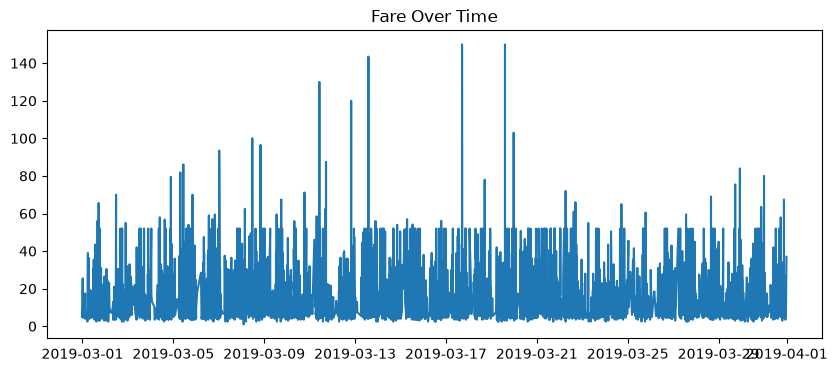

In [70]:
#★ Line Chart  

df['pickup'] = pd.to_datetime(df['pickup'])
df = df.sort_values('pickup')
plt.figure(figsize=(10, 4))
plt.plot(df['pickup'], df['fare'])
plt.title('Fare Over Time')
plt.show()

ignificant price spikes reaching $130–$150 were recorded around March 13, March 17, and March 19.

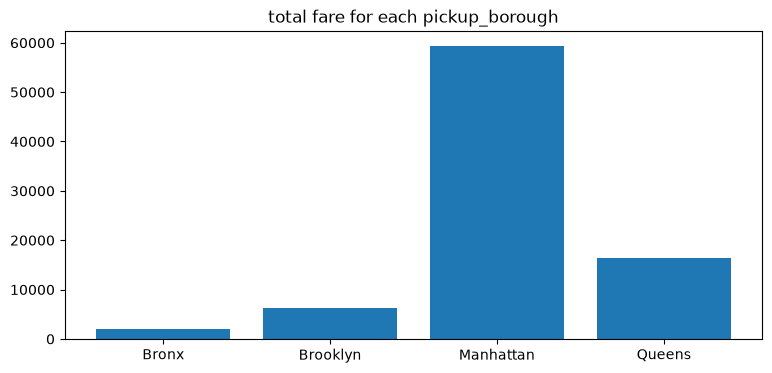

In [71]:
# ★ Bar Chart 

borough_fare = df.groupby("pickup_borough")["fare"].sum().reset_index()
plt.figure(figsize=(9, 4))
plt.bar(borough_fare['pickup_borough'], borough_fare['fare'])
plt.title("total fare for each pickup_borough")
plt.show()

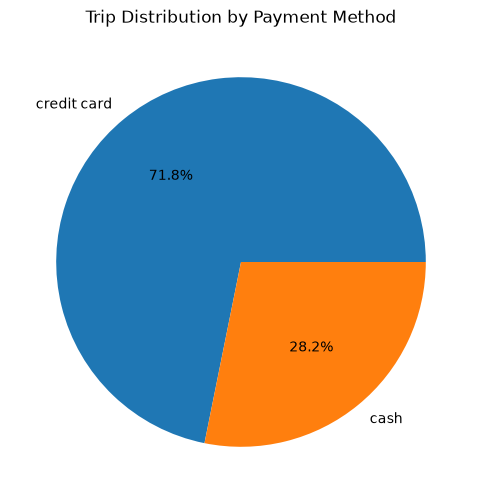

In [72]:
# Pie Chart  

counts = df['payment'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

plt.title('Trip Distribution by Payment Method')
plt.show()

Cash payments form a significantly smaller portion of overall transactions.

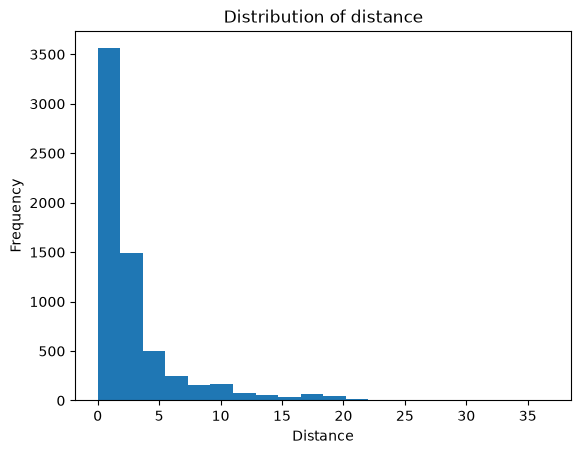

In [73]:
# ★ Histogram  
plt.hist(df["distance"], bins=20) 
plt.title("Distribution of distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

The majority of taxi trips cover short distances, mostly between 0 to 5 miles.

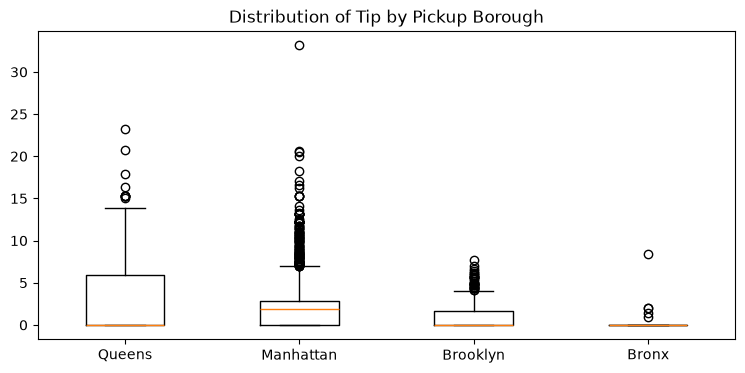

In [74]:
#  Box Plot 
boroughs = df['pickup_borough'].dropna().unique()
tips_data = [df[df['pickup_borough'] == b]['tip'].dropna() for b in boroughs]

plt.figure(figsize=(9, 4))
plt.boxplot(tips_data, tick_labels=boroughs)

plt.title("Distribution of Tip by Pickup Borough")
plt.show()

Brooklyn and Bronx show lower overall tip amounts with very low median tips.   

Visualizations using Seaborn:

C:\Users\sujeesh\AppData\Local\Temp\ipykernel_29524\1934287016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pickup_borough', palette='viridis')


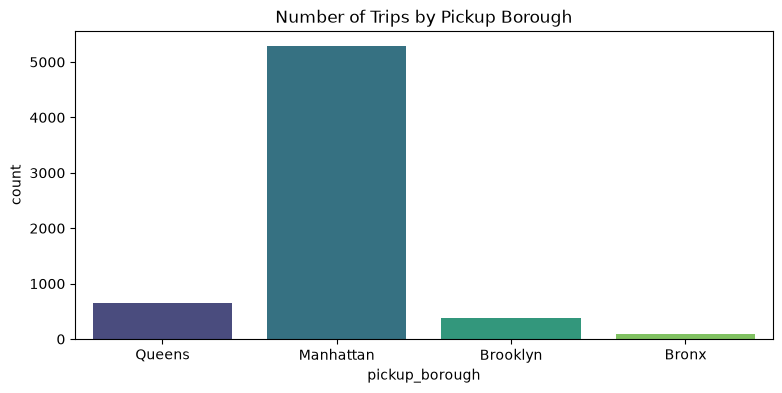

In [75]:
# ★ Count Plot 

import seaborn as sns
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='pickup_borough', palette='viridis')
plt.title("Number of Trips by Pickup Borough")
plt.show()

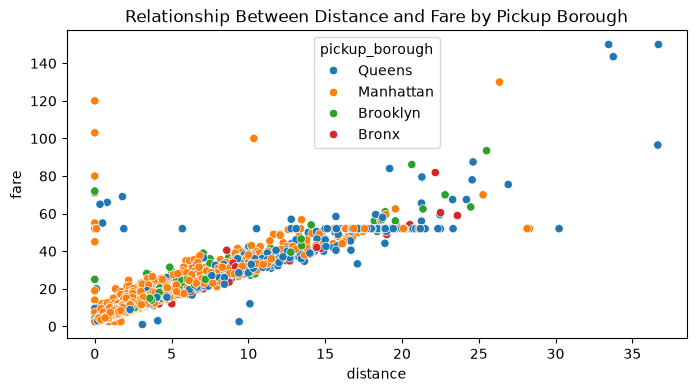

In [80]:
# ★ Scatter Plot  

plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=df, 
    x='distance', 
    y='fare', 
    hue='pickup_borough')
plt.title("Relationship Between Distance and Fare by Pickup Borough")
plt.show()

As the trip distance increases, the taxi fare generally increases as well, with the longest and most expensive trips originating from Queens and Manhattan

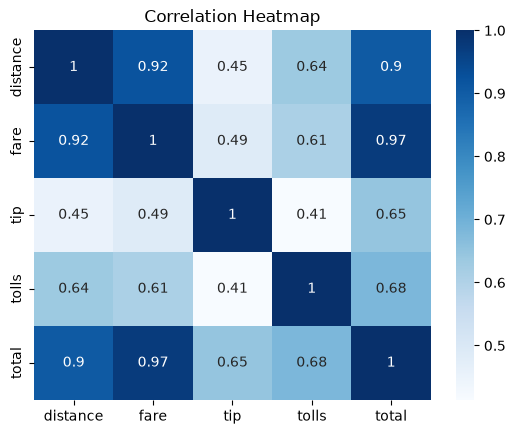

In [81]:
# ★ Heatmap 
cols = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
sns.heatmap(cols, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

Distance, fare, tip, and total amount show a strong positive correlation with each other.

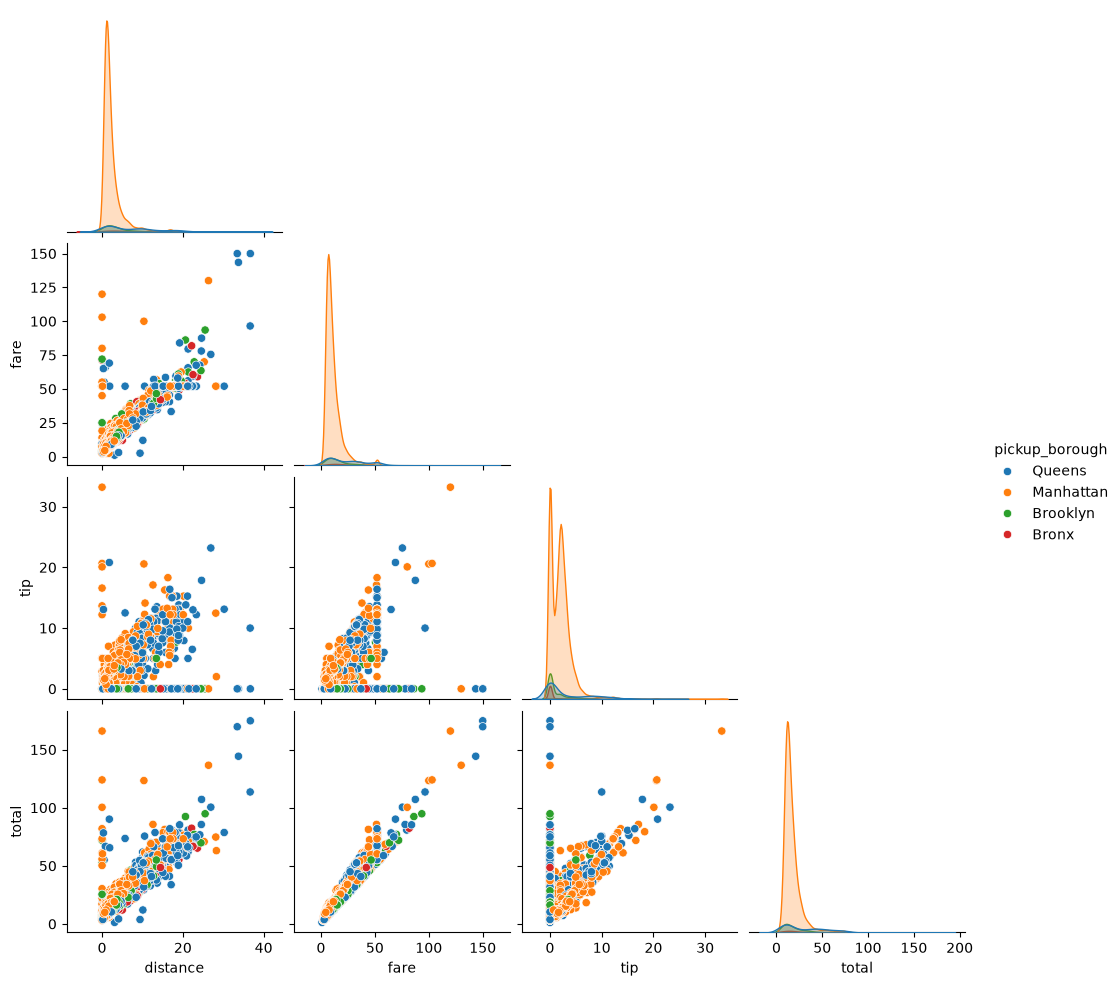

In [83]:
# ★ Pair Plot 

sns.pairplot(
    data=df, 
    vars=['distance', 'fare', 'tip', 'total'], 
    hue='pickup_borough',
    corner=True
)

plt.show()
   

C:\Users\sujeesh\AppData\Local\Temp\ipykernel_29524\4165929233.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x='payment',y='fare',palette='Set2')


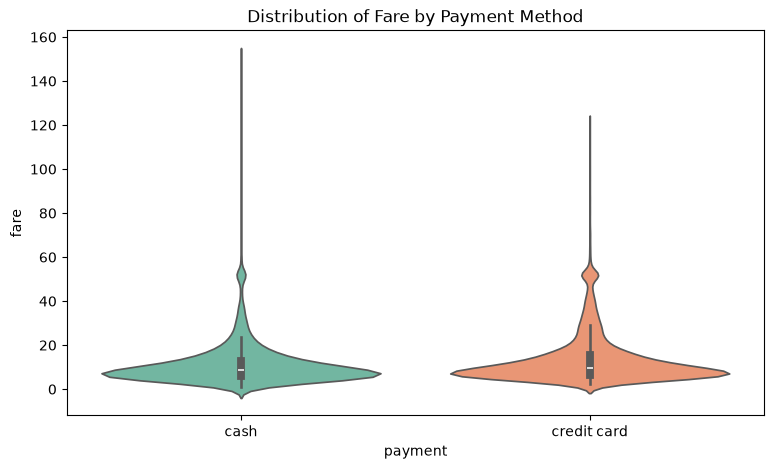

In [ ]:
# ★ Violin Plot 

plt.figure(figsize=(9, 5))
sns.violinplot(data=df,x='payment',y='fare', palette'Set2')
plt.title("Distribution of Fare by Payment Method")
plt.show()
   